# Notebook: Extrapolation Benchmark

Purpose: benchmark and debug extrapolation algorithms for seasonality and variability datasets

In [1]:

import os
import time
import json
import functools
import warnings
from pprint import pprint

import numpy as np
import xarray as xr
import geopandas as gpd
import rioxarray
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import ndimage
from scipy.spatial import cKDTree

# optional imports
try:
    from sklearn.neighbors import BallTree
    _have_ball = True
except Exception:
    BallTree = None
    _have_ball = False

# import local package helpers
from aislens.config import config
try:
    from aislens import utils as ai_utils
except Exception:
    ai_utils = None

# Notebook configuration
TIME_SLICE = 48
ICE_SHELF_START_INDEX = 33
MAX_SHELVES = 2  # for quick dry-run; set higher for full run
ALGORITHMS = ['ndimage', 'ckdtree', 'ball'] if _have_ball else ['ndimage', 'ckdtree']
SAVE_OUTPUTS = False
OUTDIR = os.path.join(config.DIR_PROCESSED if hasattr(config, 'DIR_PROCESSED') else '.', 'extrap_benchmark_outputs')
DRY_RUN = True  # if True, process up to MAX_SHELVES; set to False for full set
RANDOM_SEED = 42
sns.set(style='whitegrid')

print('Algorithms to test:', ALGORITHMS)
print('TIME_SLICE:', TIME_SLICE, 'ICE_SHELF_START_INDEX:', ICE_SHELF_START_INDEX, 'MAX_SHELVES:', MAX_SHELVES)


/var/folders/6z/tqg0lf9108s22svs6qbs4d_80131yc/T/ipykernel_2877/1278995868.py:10: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


Algorithms to test: ['ndimage', 'ckdtree', 'ball']
TIME_SLICE: 48 ICE_SHELF_START_INDEX: 33 MAX_SHELVES: 2


In [2]:

# Resolve paths from config if available
seasonality_path = getattr(config, 'FILE_SEASONALITY', None) or getattr(config, 'SORRM_SEASONALITY_PATH', None)
variability_path = getattr(config, 'FILE_VARIABILITY', None) or getattr(config, 'SORRM_VARIABILITY_PATH', None)
iceshelves_candidates = []
if hasattr(config, 'FILE_ICESHELFMASKS'):
    iceshelves_candidates.append(config.FILE_ICESHELFMASKS)
if hasattr(config, 'DIR_PROCESSED'):
    iceshelves_candidates.append(os.path.join(config.DIR_PROCESSED, 'iceShelves.geojson'))
iceshelves_candidates.append(os.path.join('data', 'external', 'iceShelves.geojson'))

print('seasonality_path:', seasonality_path)
print('variability_path:', variability_path)
print('ice-shelves candidates:', iceshelves_candidates)

# open datasets (dask-chunked for safety)
if seasonality_path and os.path.exists(str(seasonality_path)):
    ds_seas = xr.open_dataset(str(seasonality_path), chunks={config.TIME_DIM: 12})
else:
    raise FileNotFoundError('Seasonality dataset not found. Set config.FILE_SEASONALITY or FILE path.')

if variability_path and os.path.exists(str(variability_path)):
    ds_var = xr.open_dataset(str(variability_path), chunks={config.TIME_DIM: 12})
else:
    raise FileNotFoundError('Variability dataset not found. Set config.FILE_VARIABILITY or FILE path.')

# find ice shelves geojson
iceshelves_path = next((p for p in iceshelves_candidates if p and os.path.exists(str(p))), None)
if iceshelves_path is None:
    print('No iceShelves.geojson found in candidates. Please set config.FILE_ICESHELFMASKS or provide path.')
    icems = None
else:
    icems = gpd.read_file(str(iceshelves_path))
    print('Loaded ice-shelves:', len(icems), 'CRS:', icems.crs)

# show variable names and a brief summary
print('ds_seas variables:', list(ds_seas.data_vars))
print('ds_var variables:', list(ds_var.data_vars))


seasonality_path: /Users/smurugan9/research/aislens/AISLENS/data/processed/sorrm_seasonality.nc
variability_path: /Users/smurugan9/research/aislens/AISLENS/data/processed/sorrm_variability.nc
ice-shelves candidates: [PosixPath('/Users/smurugan9/research/aislens/AISLENS/data/external/iceShelves.geojson'), '/Users/smurugan9/research/aislens/AISLENS/data/processed/iceShelves.geojson', 'data/external/iceShelves.geojson']
Loaded ice-shelves: 133 CRS: epsg:4326
ds_seas variables: ['__xarray_dataarray_variable__']
ds_var variables: ['timeMonthly_avg_landIceFreshwaterFlux']
Loaded ice-shelves: 133 CRS: epsg:4326
ds_seas variables: ['__xarray_dataarray_variable__']
ds_var variables: ['timeMonthly_avg_landIceFreshwaterFlux']


In [3]:

def _select_first_n(ds, n=TIME_SLICE):
    time_dim = getattr(config, 'TIME_DIM', None)
    if time_dim and time_dim in ds.dims:
        return ds.isel({time_dim: slice(0, n)})
    else:
        # fallback to first dimension
        first_dim = list(ds.dims)[0]
        return ds.isel({first_dim: slice(0, n)})

# pick primary data variable name (normalize if necessary)
def _pick_varname(ds):
    v = list(ds.data_vars)[0]
    # handle xarray unnamed dataarray variable
    if v == '__xarray_dataarray_variable__' and hasattr(config, 'SORRM_FLUX_VAR'):
        desired = config.SORRM_FLUX_VAR
        ds = ds.rename({v: desired})
        return desired, ds
    return v, ds

# subset
var_seas, ds_seas = _pick_varname(ds_seas)
var_var, ds_var = _pick_varname(ds_var)
print('seasonality var:', var_seas, 'variability var:', var_var)

ds_seas = _select_first_n(ds_seas, TIME_SLICE)
ds_var = _select_first_n(ds_var, TIME_SLICE)

# create small in-memory samples for quick plotting (but keep original dask datasets around)
try:
    sample_seas = ds_seas.isel({getattr(config,'TIME_DIM', list(ds_seas.dims)[0]): slice(0, min(12, TIME_SLICE))}).load()
    sample_var = ds_var.isel({getattr(config,'TIME_DIM', list(ds_var.dims)[0]): slice(0, min(12, TIME_SLICE))}).load()
except Exception:
    sample_seas = ds_seas
    sample_var = ds_var

print('sample shapes (seasonality):', {k: v.shape for k,v in sample_seas.data_vars.items()})


seasonality var: timeMonthly_avg_landIceFreshwaterFlux variability var: timeMonthly_avg_landIceFreshwaterFlux
sample shapes (seasonality): {'timeMonthly_avg_landIceFreshwaterFlux': (12, 601, 601)}
sample shapes (seasonality): {'timeMonthly_avg_landIceFreshwaterFlux': (12, 601, 601)}


In [4]:

from shapely.geometry import mapping
from rasterio.features import rasterize as _rasterize
import matplotlib.path as mpath


def rasterize_icemasks(da_template, icems_gdf):
    """Return boolean mask aligned to da_template dims (y,x).
    Tries rioxarray.rio.reproject_match or rasterio rasterize, falls back to polygon containment.
    """
    if icems_gdf is None:
        return None

    # attempt rioxarray reproject_match if icems has a crs and da_template has riox metadata
    try:
        if hasattr(da_template, 'rio') and getattr(icems_gdf, 'crs', None) is not None:
            # rasterize via rasterio using template transform
            transform = da_template.rio.transform()
            out_shape = tuple(da_template.shape)
            geoms = [(mapping(g), 1) for g in icems_gdf.geometry if g is not None]
            if len(geoms) == 0:
                return None
            mask_arr = _rasterize(geoms, out_shape=out_shape, transform=transform, fill=0, dtype='uint8')
            mask = mask_arr.astype(bool)
            return xr.DataArray(mask, dims=da_template.dims, coords={dim: da_template.coords[dim] for dim in da_template.dims})
    except Exception:
        pass

    # fallback polygon containment
    try:
        y_dim, x_dim = da_template.dims[-2], da_template.dims[-1]
        x_coords = np.asarray(da_template.coords[x_dim].values)
        y_coords = np.asarray(da_template.coords[y_dim].values)
        X, Y = np.meshgrid(x_coords, y_coords)
        pts = np.vstack((X.ravel(), Y.ravel())).T
        mask_bool = np.zeros((len(y_coords), len(x_coords)), dtype=bool)
        for geom in icems_gdf.geometry:
            if geom is None:
                continue
            try:
                polys = [geom] if geom.geom_type == 'Polygon' else list(geom)
            except Exception:
                polys = [geom]
            for poly in polys:
                try:
                    exterior = np.array(poly.exterior.coords)
                    path = mpath.Path(exterior)
                    contained = path.contains_points(pts).reshape(len(y_coords), len(x_coords))
                    for interior in getattr(poly, 'interiors', []):
                        hole_path = mpath.Path(np.array(interior.coords))
                        hole_mask = hole_path.contains_points(pts).reshape(len(y_coords), len(x_coords))
                        contained = contained & (~hole_mask)
                    mask_bool |= contained
                except Exception:
                    continue
        return xr.DataArray(mask_bool, dims=(y_dim, x_dim), coords={y_dim: y_coords, x_dim: x_coords})
    except Exception:
        return None


def ensure_mask_matches(mask_da, template_da):
    # transpose/reindex if dims differ ordering
    if mask_da is None:
        return None
    if tuple(mask_da.shape) == tuple(template_da.shape):
        return mask_da
    try:
        # try transpose if dims are same set but different order
        if set(mask_da.dims) == set(template_da.dims):
            mask_da = mask_da.transpose(*template_da.dims)
            return mask_da
    except Exception:
        pass
    try:
        # reindex by nearest on coords
        reindexed = mask_da.reindex({template_da.dims[-2]: template_da.coords[template_da.dims[-2]], template_da.dims[-1]: template_da.coords[template_da.dims[-1]]}, method='nearest', fill_value=False)
        return reindexed
    except Exception:
        return mask_da


In [5]:

# All wrappers accept numpy array shape (time,y,x) or xarray DataArray; they return numpy array (time,y,x)

def _to_numpy_stack(arr):
    if isinstance(arr, xr.DataArray):
        if hasattr(arr.data, 'compute'):
            return arr.compute().values
        return arr.values
    return np.asarray(arr)


def fill_stack_ndimage(arr_stack):
    arr = _to_numpy_stack(arr_stack).astype(float)
    nt, ny, nx = arr.shape
    out = arr.copy()
    for t in range(nt):
        slice2d = arr[t]
        valid = ~np.isnan(slice2d)
        if np.all(valid) or not np.any(valid):
            continue
        try:
            res = ndimage.distance_transform_edt(~valid, return_indices=True)
        except Exception:
            # fallback to kdtree approach for this slice
            yy, xx = np.nonzero(valid)
            vals = slice2d[yy, xx]
            tree = cKDTree(np.column_stack((yy, xx)))
            all_pts = np.column_stack(np.nonzero(np.ones_like(slice2d)))
            _, idx = tree.query(all_pts, k=1)
            nearest = vals[idx].reshape(slice2d.shape)
            out[t] = np.where(valid, slice2d, nearest)
            continue
        # normalize indices
        if isinstance(res, tuple) and len(res) >= 2:
            iy, ix = res[0].astype(int), res[1].astype(int)
        else:
            arr_res = np.asarray(res).astype(int)
            iy, ix = arr_res[0], arr_res[1]
        nearest_vals = slice2d[iy, ix]
        out[t] = np.where(valid, slice2d, nearest_vals)
    return out


def fill_stack_ckdtree(arr_stack):
    arr = _to_numpy_stack(arr_stack).astype(float)
    nt, ny, nx = arr.shape
    out = arr.copy()
    grid_pts = np.column_stack(np.nonzero(np.ones((ny, nx))))
    for t in range(nt):
        slice2d = arr[t]
        valid = ~np.isnan(slice2d)
        if np.all(valid) or not np.any(valid):
            continue
        yy, xx = np.nonzero(valid)
        vals = slice2d[yy, xx]
        pts = np.column_stack((yy, xx))
        tree = cKDTree(pts)
        _, idx = tree.query(grid_pts, k=1)
        nearest = vals[idx].reshape((ny, nx))
        out[t] = np.where(valid, slice2d, nearest)
    return out


def fill_stack_ball(arr_stack):
    if not _have_ball:
        raise RuntimeError('BallTree not available')
    arr = _to_numpy_stack(arr_stack).astype(float)
    nt, ny, nx = arr.shape
    out = arr.copy()
    grid_pts = np.column_stack(np.nonzero(np.ones((ny, nx))))
    for t in range(nt):
        slice2d = arr[t]
        valid = ~np.isnan(slice2d)
        if np.all(valid) or not np.any(valid):
            continue
        yy, xx = np.nonzero(valid)
        vals = slice2d[yy, xx]
        pts = np.column_stack((yy, xx))
        tree = BallTree(pts)
        dist, idx = tree.query(grid_pts, k=1)
        nearest = vals[idx.ravel()].reshape((ny, nx))
        out[t] = np.where(valid, slice2d, nearest)
    return out

# wrapper dispatcher
FILL_DISPATCH = {
    'ndimage': fill_stack_ndimage,
    'ckdtree': fill_stack_ckdtree,
    'ball': fill_stack_ball,
}

def fill_stack(arr_stack, method='ndimage'):
    if method not in FILL_DISPATCH:
        raise ValueError(f'Unknown method: {method}')
    return FILL_DISPATCH[method](arr_stack)


In [6]:

def process_ice_shelf(template_ds, geom, method='ndimage', varname=None):
    """Clip template_ds to geom, extrapolate only inside geom, and return a DataArray of same dims
    with filled values where original was NaN (do not overwrite original finite values).
    """
    if varname is None:
        varname = list(template_ds.data_vars)[0]
    da = template_ds[varname]
    # rasterize single geom onto template
    single_gdf = gpd.GeoDataFrame(geometry=[geom], crs=getattr(icems, 'crs', None))
    mask_da = rasterize_icemasks(da.isel({getattr(config,'TIME_DIM', list(da.dims)[0]): 0}), single_gdf)
    if mask_da is None:
        # fallback: try bounding box quick test
        print('Warning: could not rasterize geom; skipping')
        return None
    mask_da = ensure_mask_matches(mask_da, da.isel({getattr(config,'TIME_DIM', list(da.dims)[0]): 0}))
    mask_bool = np.asarray(mask_da.values, dtype=bool)

    arr = _to_numpy_stack(da)
    # local copy; set values outside geometry to NaN so fill only occurs inside
    local = arr.copy()
    outside = ~mask_bool
    local[:, outside] = np.nan

    # call chosen fill algorithm
    filled_local = fill_stack(local, method=method)

    # build output array: only copy finite filled_local into places where original arr was NaN and inside mask
    out = arr.copy()
    original_nan = np.isnan(arr)
    to_fill = original_nan & (mask_bool[None, :, :]) & np.isfinite(filled_local)
    out[to_fill] = filled_local[to_fill]
    # ensure original finite preserved (safety)
    out[np.isfinite(arr)] = arr[np.isfinite(arr)]

    # return as DataArray with same coords
    new_da = xr.DataArray(out, dims=da.dims, coords=da.coords)
    return new_da


def merge_back_to_full(template_ds, filled_per_shelf, varname=None):
    """Take template_ds and list of DataArray filled_per_shelf (same dims) and write filled values into
    a copy of the full dataset only where template was NaN.
    """
    if varname is None:
        varname = list(template_ds.data_vars)[0]
    base_arr = _to_numpy_stack(template_ds[varname])
    out = base_arr.copy()
    original_nan = np.isnan(base_arr)
    for da_filled in filled_per_shelf:
        if da_filled is None:
            continue
        arr_f = _to_numpy_stack(da_filled)
        # copy finite arr_f into out only where original_nan and arr_f finite
        to_apply = original_nan & np.isfinite(arr_f)
        out[to_apply] = arr_f[to_apply]
        # update original_nan to avoid double-counting
        original_nan = np.isnan(out)
    ds_out = template_ds.copy(deep=False)
    ds_out[varname].values = out
    return ds_out


In [7]:

import concurrent.futures


def run_extrapolation_all(template_ds, icems_gdf, methods=ALGORITHMS, start_idx=ICE_SHELF_START_INDEX, max_shelves=MAX_SHELVES, parallel=False, dry_run=DRY_RUN, return_filled_per_shelf=True, verbose=True):
    results = {}
    timings = {}
    n_shelves_total = len(icems_gdf) if icems_gdf is not None else 0
    end_idx = n_shelves_total if not dry_run else min(n_shelves_total, start_idx + max_shelves)
    selection = list(range(start_idx, end_idx))
    if len(selection) == 0:
        print('No shelves selected for processing (check start_idx / MAX_SHELVES)')
        return results, timings
    print(f'Processing shelves {selection[0]}..{selection[-1]} (total {len(selection)})')

    for method in methods:
        print('\nRunning method:', method)
        method_start = time.perf_counter()
        filled_per_shelf = [None] * len(selection)
        per_shelf_times = {}

        if parallel:
            # caution: heavy IO / xarray + multiprocessing can be tricky; use threads as default
            with concurrent.futures.ThreadPoolExecutor(max_workers=4) as ex:
                futures = {}
                for i, idx in enumerate(selection):
                    geom = icems_gdf.geometry.iloc[idx]
                    if verbose:
                        print(f'  Submitting shelf {i+1}/{len(selection)} (idx={idx})')
                    futures[ex.submit(_process_single_shelf_timed, template_ds, geom, method, idx)] = i
                completed = 0
                for fut in concurrent.futures.as_completed(futures):
                    i = futures[fut]
                    idx, da_res, elapsed = fut.result()
                    filled_per_shelf[i] = da_res
                    per_shelf_times[idx] = elapsed
                    completed += 1
                    if verbose:
                        print(f'  Completed {completed}/{len(selection)}: shelf idx={idx} time={elapsed:0.2f}s')
        else:
            for i, idx in enumerate(selection):
                geom = icems_gdf.geometry.iloc[idx]
                if verbose:
                    print(f'  Processing shelf {i+1}/{len(selection)} (idx={idx})...')
                idx_res, da_res, elapsed = _process_single_shelf_timed(template_ds, geom, method, idx)
                filled_per_shelf[i] = da_res
                per_shelf_times[idx_res] = elapsed
                if verbose:
                    print(f'    Done shelf idx={idx_res} in {elapsed:0.2f}s')
        method_end = time.perf_counter()
        timings[method] = {'per_shelf': per_shelf_times, 'total_s': method_end - method_start}
        # either merge results back to full dataset (expensive) or return the per-shelf filled arrays
        if return_filled_per_shelf:
            results[method] = filled_per_shelf
            print(f"Method {method} finished in {timings[method]['total_s']:0.2f}s (returning per-shelf filled arrays; merge skipped)")
        else:
            ds_out = merge_back_to_full(template_ds, filled_per_shelf)
            results[method] = ds_out
            print(f"Method {method} finished in {timings[method]['total_s']:0.2f}s")
    return results, timings


def _process_single_shelf_timed(template_ds, geom, method, shelf_idx):
    t0 = time.perf_counter()
    da_filled = process_ice_shelf(template_ds, geom, method=method)
    t1 = time.perf_counter()
    return shelf_idx, da_filled, (t1 - t0)

# Example usage (dry run):
# results_dict, timings = run_extrapolation_all(ds_seas, icems, methods=ALGORITHMS, parallel=False, dry_run=True, return_filled_per_shelf=True, verbose=True)


In [8]:

from collections import defaultdict


def compute_metrics(original_ds, extrap_ds, varname=None):
    if varname is None:
        varname = list(original_ds.data_vars)[0]
    out = {}
    da_orig = original_ds[varname]
    da_extr = extrap_ds[varname]
    spatial_dims = [d for d in da_orig.dims if d != getattr(config,'TIME_DIM', da_orig.dims[0])]
    # spatial mean time series
    try:
        ts_orig = da_orig.mean(dim=spatial_dims).compute()
        ts_extr = da_extr.mean(dim=spatial_dims).compute()
    except Exception:
        ts_orig = da_orig.mean(dim=spatial_dims)
        ts_extr = da_extr.mean(dim=spatial_dims)
    out['spatial_mean_ts'] = (ts_orig, ts_extr)

    # apples-to-apples on orig footprint
    mask = np.isfinite(da_orig)
    extr_on_orig = da_extr.where(mask)
    diff = (extr_on_orig - da_orig).where(mask)
    vals = diff.values.ravel()[np.isfinite(diff.values.ravel())]
    out['n_points_on_orig'] = int(vals.size)
    if vals.size:
        out['diff_mean'] = float(np.mean(vals))
        out['diff_median'] = float(np.median(vals))
        out['diff_std'] = float(np.std(vals))
        out['diff_5pct'] = float(np.percentile(vals, 5))
        out['diff_95pct'] = float(np.percentile(vals, 95))
    else:
        out.update({k: float('nan') for k in ['diff_mean','diff_median','diff_std','diff_5pct','diff_95pct']})
    out['hist'] = np.histogram(vals, bins=40)

    # non-NaN counts per timestep
    try:
        out['count_per_t'] = da_extr.count(dim=spatial_dims).compute().values
    except Exception:
        out['count_per_t'] = da_extr.count(dim=spatial_dims).values
    return out


def compute_metrics_from_filled_lists(original_ds, filled_per_shelf_list, varname=None):
    """Compute lightweight apples-to-apples metrics from a list of per-shelf filled DataArrays.
    This avoids merging full datasets and is much faster for dry-runs.
    filled_per_shelf_list is the list returned for a single method by run_extrapolation_all(..., return_filled_per_shelf=True)
    """
    if varname is None:
        varname = list(original_ds.data_vars)[0]
    out = {}
    da_orig = original_ds[varname]
    orig_arr = _to_numpy_stack(da_orig)
    mask_orig = np.isfinite(orig_arr)

    vals_list = []
    total_count_per_t = None
    for da_f in filled_per_shelf_list:
        if da_f is None:
            continue
        arr_f = _to_numpy_stack(da_f)
        # apples-to-apples diffs where original is finite and filled value exists
        mask = mask_orig & np.isfinite(arr_f)
        if np.any(mask):
            vals = (arr_f - orig_arr)[mask]
            vals_list.append(vals.ravel())
        # accumulate counts per timestep for filled values (where arr_f finite)
        try:
            finite_per_t = np.isfinite(arr_f).sum(axis=(1,2))
        except Exception:
            finite_per_t = None
        if finite_per_t is not None:
            if total_count_per_t is None:
                total_count_per_t = finite_per_t.copy()
            else:
                total_count_per_t = total_count_per_t + finite_per_t

    if vals_list:
        all_vals = np.concatenate(vals_list)
    else:
        all_vals = np.array([])
    out['n_points_on_orig'] = int(all_vals.size)
    if all_vals.size:
        out['diff_mean'] = float(np.mean(all_vals))
        out['diff_median'] = float(np.median(all_vals))
        out['diff_std'] = float(np.std(all_vals))
        out['diff_5pct'] = float(np.percentile(all_vals, 5))
        out['diff_95pct'] = float(np.percentile(all_vals, 95))
    else:
        out.update({k: float('nan') for k in ['diff_mean','diff_median','diff_std','diff_5pct','diff_95pct']})
    out['hist'] = np.histogram(all_vals, bins=40)
    if total_count_per_t is not None:
        out['count_per_t'] = total_count_per_t
    else:
        out['count_per_t'] = None
    return out

# Example usage:
# metrics = {m: compute_metrics(ds_seas, results_dict[m]) for m in results_dict}
# or for per-shelf lists:
# metrics_fast = {m: compute_metrics_from_filled_lists(ds_seas, results_per_method[m]) for m in results_per_method}


In [9]:

import math

# diagnostics container for last run
PICK_DIAGNOSTICS = []

def pick_random_valid_pixel_per_shelf(original_ds, icems_gdf, start_idx=ICE_SHELF_START_INDEX, max_shelves=MAX_SHELVES, seed=RANDOM_SEED, verbose=True):
    """Return list of picks (or None) for shelves and fill PICK_DIAGNOSTICS with per-shelf info.

    Each pick is dict: {'shelf_idx', 'yx', 'name', 'n_valid', 'mask_sum', 'overlap'}
    """
    rng = np.random.default_rng(seed)
    time_dim = getattr(config, 'TIME_DIM', list(original_ds.dims)[0])
    varname = list(original_ds.data_vars)[0]
    da = original_ds[varname]
    y_dim, x_dim = da.dims[-2], da.dims[-1]
    picks = []
    PICK_DIAGNOSTICS.clear()
    n_shelves = len(icems_gdf)
    end_idx = min(n_shelves, start_idx + max_shelves)
    if verbose:
        print(f'Inspecting shelves {start_idx}..{end_idx-1}')
    for idx in range(start_idx, end_idx):
        geom = icems_gdf.geometry.iloc[idx]
        # rasterize single geometry to template grid
        try:
            mask_da = rasterize_icemasks(da.isel({time_dim:0}), gpd.GeoDataFrame(geometry=[geom], crs=icems_gdf.crs))
        except Exception as e:
            mask_da = None
            if verbose:
                print(f'shelf {idx}: rasterize failed: {e}')
        if mask_da is None:
            picks.append(None)
            PICK_DIAGNOSTICS.append({'shelf_idx': idx, 'name': icems_gdf.name.iloc[idx] if 'name' in icems_gdf.columns else f'shelf_{idx}', 'mask_sum': 0, 'n_valid': 0, 'overlap': 0})
            continue
        mask_al = ensure_mask_matches(mask_da, da.isel({time_dim:0}))
        mask_bool = np.asarray(mask_al.values, dtype=bool)
        mask_sum = int(np.count_nonzero(mask_bool))

        arr = _to_numpy_stack(da)  # (time,y,x)
        spatial_valid_any = np.any(np.isfinite(arr), axis=0)
        n_valid = int(np.count_nonzero(spatial_valid_any))
        overlap = int(np.count_nonzero(spatial_valid_any & mask_bool))

        PICK_DIAGNOSTICS.append({'shelf_idx': idx, 'name': icems_gdf.name.iloc[idx] if 'name' in icems_gdf.columns else f'shelf_{idx}', 'mask_sum': mask_sum, 'n_valid': n_valid, 'overlap': overlap})

        if verbose:
            print(f"shelf {idx} ({PICK_DIAGNOSTICS[-1]['name']}): mask_sum={mask_sum}, spatial_valid_any={n_valid}, overlap={overlap}")

        valid_any = spatial_valid_any & mask_bool
        ysxs = np.argwhere(valid_any)
        if ysxs.size == 0:
            picks.append(None)
            continue
        choice = rng.integers(0, ysxs.shape[0])
        yx = tuple(int(v) for v in ysxs[choice])
        picks.append({'shelf_idx': idx, 'yx': yx, 'name': PICK_DIAGNOSTICS[-1]['name'], 'n_valid': int(ysxs.shape[0])})
    if verbose:
        print('Picking complete. Use PICK_DIAGNOSTICS list for per-shelf counts and overlap info.')
    return picks


def plot_per_shelf_pixel_timeseries(original_ds, results_dict, picks, ncols=4, figsize=(16, 12), savepath=None):
    methods = list(results_dict.keys())
    nplots = sum(1 for p in picks if p is not None)
    if nplots == 0:
        print('No valid pixel picks to plot')
        return
    ncols = ncols
    nrows = math.ceil(nplots / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharex=True)
    axes = np.atleast_2d(axes)
    ax_iter = axes.flatten()
    time_dim = getattr(config, 'TIME_DIM', list(original_ds.dims)[0])
    varname = list(original_ds.data_vars)[0]

    palette = sns.color_palette('tab10', n_colors=max(3, len(methods)))
    method_colors = {m: palette[i % len(palette)] for i, m in enumerate(methods)}

    plot_i = 0
    for ax, p in zip(ax_iter, [pp for pp in picks if pp is not None]):
        iy, ix = p['yx']
        shelf_name = p['name']
        # original
        try:
            orig_ts = original_ds[varname].isel({original_ds[varname].dims[-2]: iy, original_ds[varname].dims[-1]: ix}).values
        except Exception:
            orig_ts = np.full((original_ds[list(original_ds.data_vars)[0]].shape[0],), np.nan)
        ax.plot(orig_ts, label='original', color='k', linewidth=1.8)
        for method, ds_out in results_dict.items():
            try:
                ex_ts = ds_out[varname].isel({ds_out[varname].dims[-2]: iy, ds_out[varname].dims[-1]: ix}).values
            except Exception:
                ex_ts = np.full_like(orig_ts, np.nan)
            ax.plot(ex_ts, label=method, color=method_colors[method], linewidth=1.2, alpha=0.9)
        ax.set_title(shelf_name, fontsize=9)
        ax.grid(True, linewidth=0.3)
        plot_i += 1

    # hide any extra subplots
    for j in range(plot_i, len(ax_iter)):
        ax_iter[j].axis('off')

    # single legend
    handles, labels = ax_iter[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize=9)
    fig.suptitle('Per-shelf selected pixel time series (original vs methods)', fontsize=12)
    fig.tight_layout(rect=[0,0,0.95,0.96])
    if savepath:
        fig.savefig(savepath, dpi=200)
        print('Saved per-shelf pixel timeseries to', savepath)
    plt.show()


In [10]:

# improved map plotting to match style from -extrap notebook
import cartopy.crs as ccrs

def _compute_vrange(da_slice, clip_pct=(1,99)):
    try:
        vals = da_slice.values.ravel()
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            return None, None
        lo = np.percentile(vals, clip_pct[0])
        hi = np.percentile(vals, clip_pct[1])
        # make symmetric around zero if centered data
        if lo < 0 and hi > 0:
            m = max(abs(lo), abs(hi))
            return -m, m
        return lo, hi
    except Exception:
        return None, None


def plot_map_for_time(ds_obj, t_index=0, varname=None, title=None, cmap='RdBu_r'):
    if varname is None:
        varname = list(ds_obj.data_vars)[0]
    da = ds_obj[varname]
    try:
        da_t = da.isel({getattr(config,'TIME_DIM', da.dims[0]): t_index})
    except Exception:
        da_t = da.isel({da.dims[0]: t_index})

    # compute plotting range robustly
    vmin, vmax = _compute_vrange(da_t)

    fig = plt.figure(figsize=(12,10))
    ax = plt.subplot(1,1,1, projection=ccrs.SouthPolarStereo())
    try:
        # try using PlateCarree transform for lat/lon datasets
        if vmin is not None and vmax is not None:
            im = da_t.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
        else:
            im = da_t.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap, add_colorbar=False)
    except Exception:
        # fallback to default plot (no transform)
        if vmin is not None and vmax is not None:
            im = da_t.plot(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
        else:
            im = da_t.plot(ax=ax, cmap=cmap, add_colorbar=False)

    # overlay ice-shelf boundaries if available
    if icems is not None:
        try:
            icems.boundary.plot(ax=ax, color='k', linewidth=0.25, zorder=4)
        except Exception:
            pass

    # add coastlines and grid
    ax.coastlines(lw=0.3)
    ax.gridlines(draw_labels=False, linewidth=0.2, color='gray', alpha=0.5)

    # colorbar
    cb = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.035, pad=0.04)
    cb.ax.tick_params(labelsize=8)

    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()

# diff map (masked to original footprint)
def plot_diff_map(original_ds, extrap_ds, t_index=0, cmap='RdBu_r'):
    varname = list(original_ds.data_vars)[0]
    try:
        a = original_ds[varname].isel({getattr(config,'TIME_DIM', original_ds[varname].dims[0]): t_index})
        b = extrap_ds[varname].isel({getattr(config,'TIME_DIM', extrap_ds[varname].dims[0]): t_index})
    except Exception:
        a = original_ds[varname].isel({original_ds[varname].dims[0]: t_index})
        b = extrap_ds[varname].isel({extrap_ds[varname].dims[0]: t_index})
    mask = np.isfinite(a)
    diff = (b - a).where(mask)
    vmin, vmax = _compute_vrange(diff)
    plot_map_for_time(diff.to_dataset(name='diff'), t_index=0, varname='diff', title='diff (extr - orig) masked to orig', cmap=cmap)


In [11]:

import os

# netCDF streaming helper
try:
    import netCDF4
    _have_netCDF4 = True
except Exception:
    netCDF4 = None
    _have_netCDF4 = False


def stream_merge_and_save(template_ds, filled_per_shelf_list, outpath, varname=None, time_dim=None, chunk_t=1, compress=True, verbose=True):
    """Merge per-shelf filled arrays into a NetCDF file by streaming per-time-slice and writing updates.

    - template_ds: xarray.Dataset (template)
    - filled_per_shelf_list: list of DataArray (or None) returned by run_extrapolation_all(..., return_filled_per_shelf=True)
    - outpath: output netcdf path
    - varname: variable name to write (defaults to first)
    - time_dim: name of time dimension
    - chunk_t: number of timesteps per write chunk (1 = per-t)
    """
    if not _have_netCDF4:
        raise RuntimeError('netCDF4 not available for streaming writes')
    if varname is None:
        varname = list(template_ds.data_vars)[0]
    if time_dim is None:
        time_dim = getattr(config, 'TIME_DIM', template_ds[varname].dims[0])

    # open/create netcdf
    nt = int(template_ds.dims[time_dim])
    y_dim = template_ds[varname].dims[-2]
    x_dim = template_ds[varname].dims[-1]
    ny = int(template_ds.dims[y_dim])
    nx = int(template_ds.dims[x_dim])

    # dtype and fillvalue
    dtype = 'f4'
    fill_value = np.nan

    os.makedirs(os.path.dirname(outpath) or '.', exist_ok=True)
    ds_nc = netCDF4.Dataset(outpath, 'w', format='NETCDF4')
    ds_nc.createDimension(time_dim, nt)
    ds_nc.createDimension(y_dim, ny)
    ds_nc.createDimension(x_dim, nx)

    var_nc = ds_nc.createVariable(varname, dtype, (time_dim, y_dim, x_dim), zlib=bool(compress), chunksizes=(chunk_t, ny, nx))
    var_nc.setncattr('_FillValue', np.float32(np.nan))

    # write template data into file in chunks
    if verbose:
        print('Writing template data into', outpath)
    for t in range(nt):
        try:
            slice_da = template_ds[varname].isel({time_dim: t})
        except Exception:
            slice_da = template_ds[varname].isel({template_ds[varname].dims[0]: t})
        try:
            arr = slice_da.compute().values
        except Exception:
            arr = slice_da.values
        # ensure float32
        arr = np.asarray(arr, dtype=np.float32)
        var_nc[t, :, :] = arr
        if verbose and (t % max(1, nt//10) == 0):
            print(f'  wrote time slice {t+1}/{nt}')

    # Now apply per-shelf filled arrays (only write into positions where original was NaN)
    # We'll iterate time-by-time and for each time read the current slice and apply updates from each shelf
    if verbose:
        print('Applying per-shelf fills to file (streaming)')

    for t in range(nt):
        # read current slice
        current = var_nc[t, :, :].astype(np.float32)[:]
        try:
            orig_slice = template_ds[varname].isel({time_dim: t}).compute().values
        except Exception:
            orig_slice = template_ds[varname].isel({template_ds[varname].dims[0]: t}).values
        orig_nan = np.isnan(orig_slice)
        updated = False
        for i, da_f in enumerate(filled_per_shelf_list):
            if da_f is None:
                continue
            arr_f = _to_numpy_stack(da_f)
            # arr_f shape is (time,y,x)
            if np.isfinite(arr_f[t]).any():
                mask = np.isfinite(arr_f[t]) & orig_nan
                if np.any(mask):
                    current[mask] = arr_f[t][mask]
                    updated = True
        if updated:
            var_nc[t, :, :] = current
        if verbose and (t % max(1, nt//10) == 0):
            print(f'  merged fills for time slice {t+1}/{nt}')

    ds_nc.close()
    if verbose:
        print('Streaming merge complete. Output written to', outpath)
    return outpath


def save_results(results_dict, timings, metrics, outdir=OUTDIR):
    os.makedirs(outdir, exist_ok=True)
    meta = {'timings': timings}
    with open(os.path.join(outdir, 'timings.json'), 'w') as fh:
        json.dump(meta, fh, indent=2)

    for method, ds_or_list in results_dict.items():
        outpath = os.path.join(outdir, f'extrap_{method}.nc')
        # if we received a list (per-shelf filled arrays), stream-merge to disk
        if isinstance(ds_or_list, list):
            print('Saving (stream merge) for method', method)
            try:
                stream_merge_and_save(ds_seas, ds_or_list, outpath, verbose=True)
            except Exception as e:
                print('Streaming merge failed for', method, 'falling back to full merge:', e)
                # fallback: merge into memory then write
                try:
                    ds_out = merge_back_to_full(ds_seas, ds_or_list)
                    ds_out = ds_out.load()
                    ds_out.to_netcdf(outpath)
                except Exception as e2:
                    print('Fallback save also failed for', method, e2)
        else:
            print('Saving dataset for method', method)
            try:
                ds_out = ds_or_list.load()
            except Exception:
                ds_out = ds_or_list
            ds_out.to_netcdf(outpath)
    # save metrics
    with open(os.path.join(outdir, 'metrics.json'), 'w') as fh:
        json.dump(metrics, fh, indent=2)
    print('Saved outputs to', outdir)

# Example usage:
# if SAVE_OUTPUTS:
#     save_results(results_dict, timings, metrics)


Processing shelves 33..34 (total 2)

Running method: ndimage
  Processing shelf 1/2 (idx=33)...
    Done shelf idx=33 in 0.59s
  Processing shelf 2/2 (idx=34)...
    Done shelf idx=34 in 0.45s
Method ndimage finished in 1.05s (returning per-shelf filled arrays; merge skipped)

Running method: ckdtree
  Processing shelf 1/2 (idx=33)...
    Done shelf idx=33 in 0.46s
  Processing shelf 2/2 (idx=34)...
    Done shelf idx=34 in 0.44s
Method ckdtree finished in 0.90s (returning per-shelf filled arrays; merge skipped)

Running method: ball
  Processing shelf 1/2 (idx=33)...
    Done shelf idx=33 in 0.43s
  Processing shelf 2/2 (idx=34)...
    Done shelf idx=34 in 0.41s
Method ball finished in 0.84s (returning per-shelf filled arrays; merge skipped)
{'ball': {'n_points_on_orig': 22766016, 'total_s': 0.836174541967921},
 'ckdtree': {'n_points_on_orig': 22766016, 'total_s': 0.8989171659341082},
 'ndimage': {'n_points_on_orig': 22766016, 'total_s': 1.0523073750082403}}


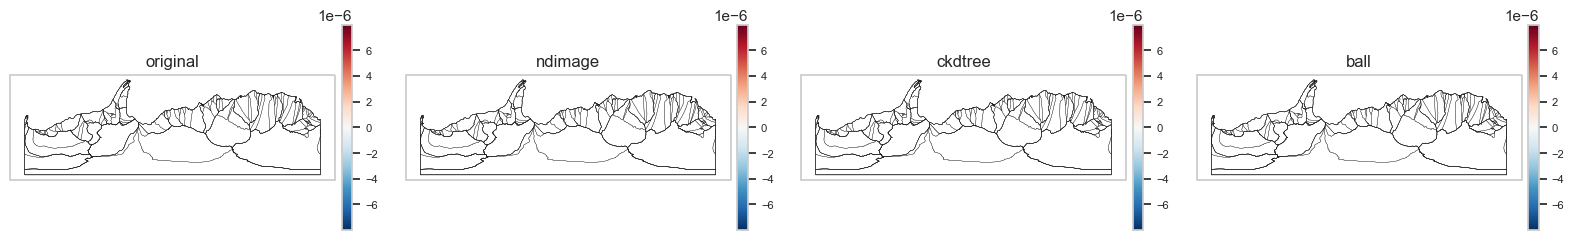

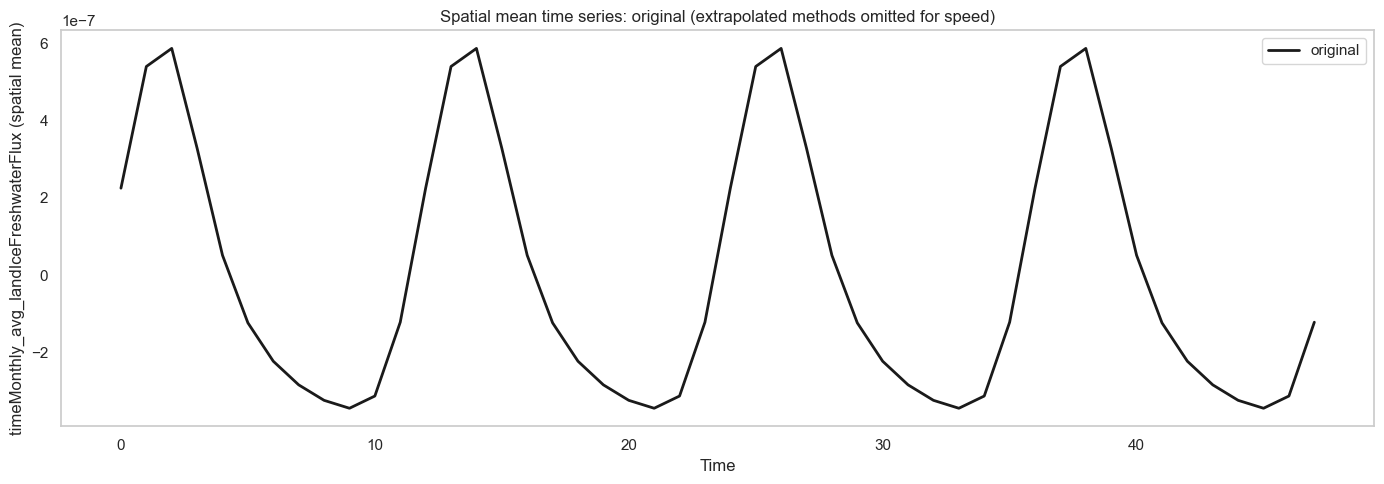

Inspecting shelves 33..34
shelf 33 (Abbot): mask_sum=0, spatial_valid_any=237146, overlap=0
shelf 34 (Amery): mask_sum=0, spatial_valid_any=237146, overlap=0
Picking complete. Use PICK_DIAGNOSTICS list for per-shelf counts and overlap info.
No valid pixel picks to plot


In [12]:

# Demonstration run
if icems is None:
    print('No ice-shelf masks available; aborting demo run.')
else:
    template_ds = ds_seas
    methods = ALGORITHMS
    # Ask for per-shelf filled arrays to avoid expensive merging of full datasets
    results_dict, timings = run_extrapolation_all(template_ds, icems, methods=methods, start_idx=ICE_SHELF_START_INDEX, max_shelves=MAX_SHELVES, parallel=False, dry_run=DRY_RUN, return_filled_per_shelf=True)

    # compute lightweight metrics from per-shelf filled arrays (fast)
    metrics = {m: compute_metrics_from_filled_lists(ds_seas, results_dict[m]) for m in results_dict}

    # print concise timing + filled counts (if available)
    summary = {}
    for m in timings:
        n_points = metrics[m].get('n_points_on_orig', None)
        summary[m] = {'total_s': float(timings[m]['total_s']), 'n_points_on_orig': n_points}
    pprint(summary)

    # --- comparison maps (original + each method) at time index 0 as 1xN subplot ---
    # Note: creating merged full datasets for plotting is expensive. Only do this when MAX_SHELVES is small (dry-run) and user expects maps.
    try:
        var = list(ds_seas.data_vars)[0]
        time_dim = getattr(config, 'TIME_DIM', ds_seas[var].dims[0])
        # collect slices
        slices = []
        names = []
        # original
        try:
            orig_slice = ds_seas[var].isel({time_dim: 0})
        except Exception:
            orig_slice = ds_seas[var].isel({ds_seas[var].dims[0]: 0})
        slices.append(orig_slice)
        names.append('original')

        # only merge per-method into a full dataset for plotting when running small dry-runs
        do_merge_for_plot = DRY_RUN and MAX_SHELVES <= 5
        merged_cache = {}
        for method, per_shelf_list in results_dict.items():
            if do_merge_for_plot:
                try:
                    ds_out = merge_back_to_full(template_ds, per_shelf_list)
                    s = ds_out[var].isel({time_dim: 0})
                except Exception:
                    s = xr.full_like(orig_slice, np.nan)
            else:
                # create a placeholder empty slice (plotting will show blank)
                s = xr.full_like(orig_slice, np.nan)
            slices.append(s)
            names.append(method)

        # compute common vmin/vmax from combined slices (robust percentiles)
        all_vals = np.hstack([np.ravel(s.values) for s in slices if np.isfinite(s.values).any()])
        if all_vals.size:
            lo = np.nanpercentile(all_vals, 1)
            hi = np.nanpercentile(all_vals, 99)
            if lo < 0 and hi > 0:
                m = np.max([abs(lo), abs(hi)]); vmin, vmax = -m, m
            else:
                vmin, vmax = lo, hi
        else:
            vmin, vmax = None, None

        ncols = len(slices)
        fig = plt.figure(figsize=(4*ncols, 6))
        import cartopy.crs as ccrs
        for i, (s, nm) in enumerate(zip(slices, names)):
            ax = fig.add_subplot(1, ncols, i+1, projection=ccrs.SouthPolarStereo())
            try:
                if vmin is not None and vmax is not None:
                    im = s.plot(ax=ax, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax, cmap='RdBu_r', add_colorbar=False)
                else:
                    im = s.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', add_colorbar=False)
            except Exception:
                if vmin is not None and vmax is not None:
                    im = s.plot(ax=ax, vmin=vmin, vmax=vmax, cmap='RdBu_r', add_colorbar=False)
                else:
                    im = s.plot(ax=ax, cmap='RdBu_r', add_colorbar=False)
            if icems is not None:
                try:
                    icems.boundary.plot(ax=ax, color='k', linewidth=0.2)
                except Exception:
                    pass
            ax.coastlines(lw=0.3)
            ax.set_title(nm)
            # add colorbar per column (small)
            cb = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.03, pad=0.02)
            cb.ax.tick_params(labelsize=8)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('Comparison map plotting failed:', e)

    # plot spatial mean time series for original + methods (we show only original here for speed)
    plt.figure(figsize=(14,5))
    var = list(ds_seas.data_vars)[0]
    spatial_dims = [d for d in ds_seas[var].dims if d != getattr(config,'TIME_DIM', ds_seas[var].dims[0])]
    try:
        orig_ts = ds_seas[var].mean(dim=spatial_dims).compute()
    except Exception:
        orig_ts = ds_seas[var].mean(dim=spatial_dims)
    plt.plot(orig_ts, label='original', color='k', linewidth=2)
    plt.xlabel('Time')
    plt.ylabel(var + ' (spatial mean)')
    plt.title('Spatial mean time series: original (extrapolated methods omitted for speed)')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    # pick pixels and plot per-shelf pixel timeseries
    picks = pick_random_valid_pixel_per_shelf(ds_seas, icems, start_idx=ICE_SHELF_START_INDEX, max_shelves=MAX_SHELVES)
    plot_per_shelf_pixel_timeseries(ds_seas, {m: (merge_back_to_full(template_ds, results_dict[m]) if DRY_RUN and MAX_SHELVES<=5 else {}) for m in results_dict}, picks, ncols=4)

    # optionally save
    if SAVE_OUTPUTS:
        # to save we need to merge; warn the user
        print('Saving outputs: merging per-shelf arrays into full datasets (this may take time)...')
        save_results({m: merge_back_to_full(template_ds, results_dict[m]) for m in results_dict}, timings, metrics)
